ML:
1. Wasserstein: 3 pairs: (b_0(f),b_0(g)) (b_0^1(f),b_0^1(g)) (b_1(f)U b_2(g),b_1(g) Ub_2(f))
2. Persistence Image: Gassusian +b_1 - b_2

In [1]:
import sys
sys.path.append('/root/Codes/graph-mph0/build')
import abmph
import numpy as np

In [2]:
np.random.seed(10) # disconnected graph. to be debug 
# np.random.seed(20)
n_nodes = 4
n_edges = 6
nodes = np.arange(1, n_nodes+1, dtype=int)
edges = np.random.randint(1, n_nodes+1, size=(n_edges, 2))
node_features = np.zeros(shape=(n_nodes, 2), dtype = np.double)
edge_features = np.random.randint(1, 10, size=(n_edges, 2)).astype(np.double)
edge_str_labels = [f"({int(row[0])},{int(row[1])})" for row in edge_features]
# edge_labels = {(row[0],row[1]):  edge_str_labels[i] for i, row in enumerate(edges) }
# edges, edge_features, edge_str_labels, edge_labels
nodes, edges

(array([1, 2, 3, 4]),
 array([[2, 2],
        [1, 4],
        [1, 2],
        [4, 1],
        [2, 2],
        [1, 2]]))

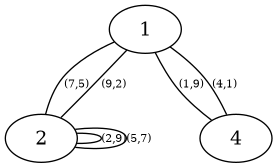

In [3]:
import pygraphviz as pgv
import matplotlib.pyplot as plt
from PIL import Image
# Create a new AGraph (directed graph)
G = pgv.AGraph(strict=False, directed=False)

for i, row in enumerate(edges):
    G.add_edge(row[0], row[1], label=edge_str_labels[i])
    
# Draw the graph to a file
G.layout(prog='dot',args="-Efontsize=8")  # Use the 'dot' layout engine
G.draw('graph.png')

# Display the graph using PIL
img = Image.open('graph.png')
img.show()

In [4]:
# Create the Graph object
mph_g = abmph.Graph(nodes, node_features, edges, edge_features)

ic| node_features: [(0, 0), (0, 0), (0, 0), (0, 0)]
ic| edges_input: [(2, 2), (1, 4), (1, 2), (4, 1), (2, 2), (1, 2)]


In [5]:
mph_g.print_adjacency()

Print Adjacency
v = 4: Edge(1, 4, id = 2) Edge(1, 4, id = 4) 
v = 3: 
v = 1: Edge(1, 4, id = 2) Edge(1, 2, id = 3) Edge(1, 4, id = 4) Edge(1, 2, id = 6) 
v = 2: Edge(2, 2, id = 1) Edge(2, 2, id = 1) Edge(1, 2, id = 3) Edge(2, 2, id = 5) Edge(2, 2, id = 5) Edge(1, 2, id = 6) 


In [6]:
mph_g.print_filtration_value()

Graph filtration values:
Vertices:
f(1) = (0, 0)
f(2) = (0, 0)
f(3) = (0, 0)
f(4) = (0, 0)
edge_values:
e = Edge(1, 2, id = 6), f(e)= (9, 2)
e = Edge(2, 2, id = 5), f(e)= (5, 7)
e = Edge(1, 4, id = 4), f(e)= (4, 1)
e = Edge(1, 2, id = 3), f(e)= (7, 5)
e = Edge(1, 4, id = 2), f(e)= (1, 9)
e = Edge(2, 2, id = 1), f(e)= (2, 9)


In [7]:
abmph.compute_MPH0_Dengrogram(mph_g)

{'b_0': [(0.0, 0.0)],
 'b_1': [(1.0, 9.0), (4.0, 1.0), (7.0, 5.0), (9.0, 2.0)],
 'b_2': [(4.0, 9.0), (9.0, 5.0)],
 'b_0_1': [(2.0, 9.0), (4.0, 9.0), (5.0, 7.0), (9.0, 5.0)],
 'M': [(1, 1, -1),
  (1, 1, 1),
  (1, 2, -1),
  (1, 2, 1),
  (1, 3, -1),
  (1, 3, 1),
  (1, 4, -1),
  (1, 4, 1)]}

In [9]:
abmph.compute_MPH0_DTree(mph_g)

{'b_0': [(0.0, 0.0)],
 'b_1': [(1.0, 9.0), (4.0, 1.0), (7.0, 5.0), (9.0, 2.0)],
 'b_2': [(4.0, 9.0), (9.0, 5.0)],
 'b_0_1': [(2.0, 9.0), (4.0, 9.0), (5.0, 7.0), (9.0, 5.0)],
 'M': [(1, 1, -1),
  (1, 1, 1),
  (1, 2, -1),
  (1, 2, 1),
  (1, 3, -1),
  (1, 3, 1),
  (1, 4, -1),
  (1, 4, 1)]}

## dgl graph to mph graph

In [6]:
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl.data
import numpy as np
dataset = dgl.data.TUDataset(name = 'Cuneiform', raw_dir='../data')
print('Number of categories:', dataset.num_classes)

/root/miniconda3/envs/dl/lib/python3.10/site-packages/torchdata/datapipes/__init__.py:18: UserWarning: 
################################################################################
WARNING!
The 'datapipes', 'dataloader2' modules are deprecated and will be removed in a
future torchdata release! Please see https://github.com/pytorch/data/issues/1196
to learn more and leave feedback.
################################################################################

  deprecation_warning()
/root/miniconda3/envs/dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of categories: 30


In [7]:
len(dataset)

267

In [8]:
g, label = dataset[0]
g

Graph(num_nodes=36, num_edges=180,
      ndata_schemes={'_ID': Scheme(shape=(), dtype=torch.int64), 'node_attr': Scheme(shape=(3,), dtype=torch.float64), 'node_labels': Scheme(shape=(2,), dtype=torch.int64)}
      edata_schemes={'_ID': Scheme(shape=(), dtype=torch.int64), 'node_labels': Scheme(shape=(2,), dtype=torch.float64), 'edge_labels': Scheme(shape=(1,), dtype=torch.int64)})

In [9]:
g.nodes().numpy()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35])

In [10]:
e_0s, e_1s, e_ids = g.edges(form='all',  order='srcdst')
e_0s

tensor([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  2,  2,  2,  3,
         3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  5,  5,  6,  6,
         6,  7,  7,  7,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,
        10, 10, 10, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13,
        13, 13, 14, 14, 14, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
        16, 17, 17, 17, 18, 18, 18, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20,
        20, 20, 20, 21, 21, 21, 22, 22, 22, 23, 23, 23, 24, 24, 24, 24, 24, 24,
        24, 24, 24, 24, 24, 25, 25, 25, 26, 26, 26, 27, 27, 27, 28, 28, 28, 28,
        28, 28, 28, 28, 28, 28, 28, 29, 29, 29, 30, 30, 30, 31, 31, 31, 32, 32,
        32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 34, 34, 34, 35, 35, 35])

In [11]:
from sklearn.preprocessing import StandardScaler

node_labels = g.nodes().numpy()
node_features = np.zeros((node_labels.shape[0], 2))
edges_input = np.vstack((e_0s.numpy(), e_1s.numpy())).T
# Create a StandardScaler object
scaler = StandardScaler()
edge_features = scaler.fit_transform(g.edata['node_labels'].numpy())

In [12]:
np.save("../data/node_labels.npy", node_labels)
np.save("../data/node_features.npy", node_features)
np.save("../data/edges_input.npy", edges_input)
np.save("../data/edge_features.npy", edge_features)

In [13]:
def standardize_array(arr):
    # Step 1: Normalize to [0, 1]
    arr_min = np.min(arr)
    arr_max = np.max(arr)
    arr_normalized = (arr - arr_min) / (arr_max - arr_min)

    # Step 2: Adjust standard deviation to 1
    arr_std = np.std(arr_normalized)
    arr_standardized = arr_normalized / arr_std
    return arr_standardized


node_labels = np.load("../data/node_labels.npy")
node_features = np.zeros((node_labels.shape[0], 2))
edges_input = np.load("../data/edges_input.npy")
edge_features = standardize_array(np.load("../data/edge_features.npy"))

g2 = abmph.Graph(node_labels, node_features, edges_input, edge_features)

In [14]:
res_den = abmph.compute_MPH0_Dengrogram(g2)

Done with Algo 2


In [15]:
res_dt = abmph.compute_MPH0_DTree(g2)

In [21]:
len(res_den['b_1']) == len(res_dt['b_1'])

False

In [25]:
for i, k in enumerate(res_den['b_1']):
    if res_dt['b_1'][i] == k:
        print("index = ", i, " same")
    else:
        print("!!! index = ", i)

index =  0  same
index =  1  same
index =  2  same
index =  3  same
index =  4  same
index =  5  same
index =  6  same
index =  7  same
index =  8  same
!!! index =  9
!!! index =  10
!!! index =  11
!!! index =  12
!!! index =  13
!!! index =  14
!!! index =  15
!!! index =  16
!!! index =  17
!!! index =  18
!!! index =  19
!!! index =  20
!!! index =  21
!!! index =  22
!!! index =  23
!!! index =  24
!!! index =  25
!!! index =  26
!!! index =  27
!!! index =  28
!!! index =  29
index =  30  same
index =  31  same
index =  32  same
index =  33  same
index =  34  same
index =  35  same
index =  36  same
index =  37  same
index =  38  same
index =  39  same
index =  40  same
index =  41  same
index =  42  same
index =  43  same
index =  44  same
index =  45  same
!!! index =  46
!!! index =  47
!!! index =  48
!!! index =  49
!!! index =  50
!!! index =  51
!!! index =  52
!!! index =  53
